In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nChurn breakdown:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn breakdown:
No     5174
Yes    1869
Name: Churn, dtype: int64

Churn rate: 26.5%


In [3]:
# Fix TotalCharges — it's a string with some blank values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop the 11 rows with nulls (new customers with no charges yet)
df.dropna(inplace=True)

# Drop customerID — not useful for analysis
df.drop('customerID', axis=1, inplace=True)

# Convert Churn to binary
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

print("Cleaned shape:", df.shape)
print("Null values:", df.isnull().sum().sum())
print("\nData types:")
print(df.dtypes.value_counts())

Cleaned shape: (7032, 21)
Null values: 0

Data types:
object     16
int64       2
float64     2
int32       1
dtype: int64


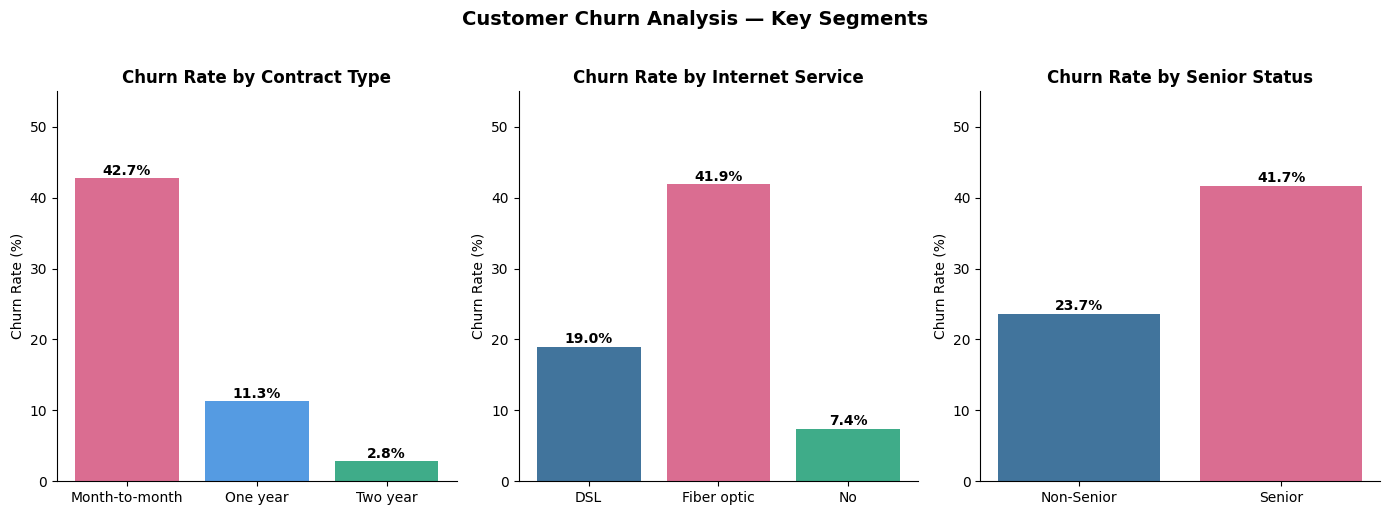

Chart saved!


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Chart 1: Churn by contract type
contract_churn = df.groupby('Contract')['Churn_binary'].mean() * 100
axes[0].bar(contract_churn.index, contract_churn.values, 
            color=['#D4537E', '#378ADD', '#1D9E75'], alpha=0.85)
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 55)
for i, v in enumerate(contract_churn.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 2: Churn by internet service
internet_churn = df.groupby('InternetService')['Churn_binary'].mean() * 100
axes[1].bar(internet_churn.index, internet_churn.values,
            color=['#1F5C8B', '#D4537E', '#1D9E75'], alpha=0.85)
axes[1].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 55)
for i, v in enumerate(internet_churn.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 3: Churn by senior citizen status
senior_churn = df.groupby('SeniorCitizen')['Churn_binary'].mean() * 100
axes[2].bar(['Non-Senior', 'Senior'], senior_churn.values,
            color=['#1F5C8B', '#D4537E'], alpha=0.85)
axes[2].set_title('Churn Rate by Senior Status', fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].set_ylim(0, 55)
for i, v in enumerate(senior_churn.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Customer Churn Analysis — Key Segments', 
             fontsize=14, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.savefig('../outputs/charts/01_churn_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

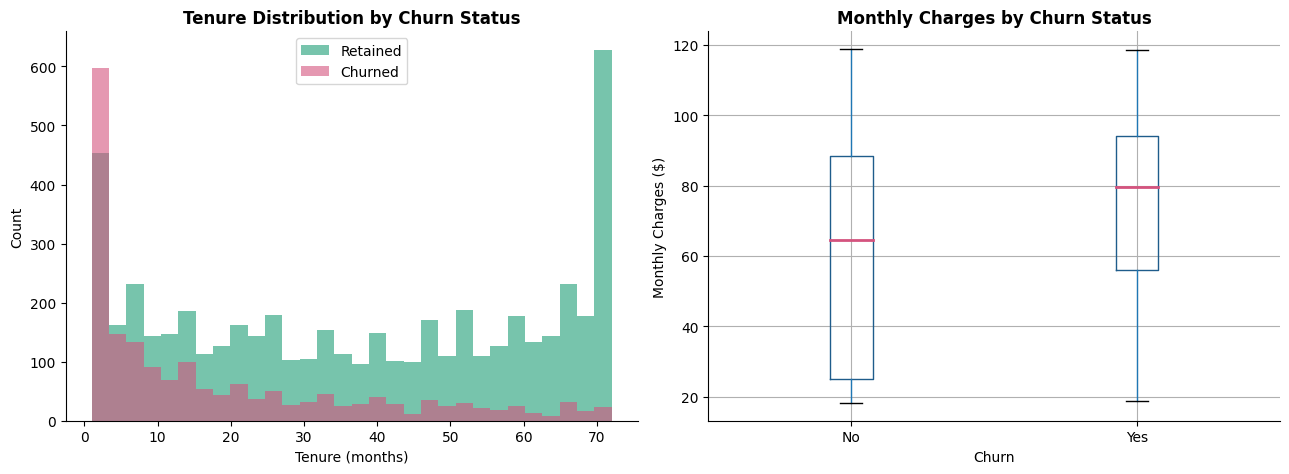

Chart saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tenure distribution by churn
churned = df[df['Churn'] == 'Yes']['tenure']
retained = df[df['Churn'] == 'No']['tenure']

axes[0].hist(retained, bins=30, alpha=0.6, color='#1D9E75', label='Retained')
axes[0].hist(churned, bins=30, alpha=0.6, color='#D4537E', label='Churned')
axes[0].set_title('Tenure Distribution by Churn Status', fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Monthly charges vs churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1],
           boxprops=dict(color='#1F5C8B'),
           medianprops=dict(color='#D4537E', linewidth=2))
axes[1].set_title('Monthly Charges by Churn Status', fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Monthly Charges ($)')
plt.suptitle('')

sns.despine()
plt.tight_layout()
plt.savefig('../outputs/charts/02_tenure_charges.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [6]:
# Encode categorical variables
df_model = df.copy()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Churn')

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Features and target
X = df_model.drop(['Churn', 'Churn_binary'], axis=1)
y = df_model['Churn_binary']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print("=" * 45)
print("MODEL PERFORMANCE")
print("=" * 45)
print(f"ROC-AUC Score:     {auc:.3f}")
print(f"Training samples:  {len(X_train):,}")
print(f"Test samples:      {len(X_test):,}")
print()
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

MODEL PERFORMANCE
ROC-AUC Score:     0.834
Training samples:  5,625
Test samples:      1,407

              precision    recall  f1-score   support

    Retained       0.85      0.88      0.86      1033
     Churned       0.62      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



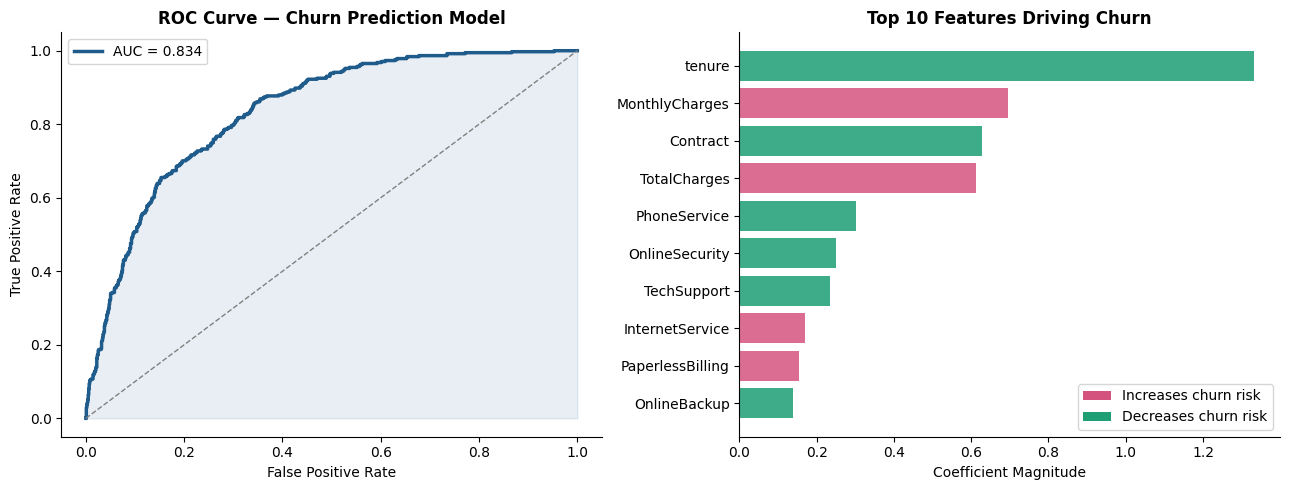

Chart saved! AUC = 0.834


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#1F5C8B', linewidth=2.5, label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#1F5C8B')
axes[0].set_title('ROC Curve — Churn Prediction Model', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Top 10 feature importances
feat_imp = pd.Series(model.coef_[0], index=X.columns)
feat_imp_top = feat_imp.abs().sort_values(ascending=True).tail(10)
colors = ['#D4537E' if feat_imp[i] > 0 else '#1D9E75' for i in feat_imp_top.index]
axes[1].barh(feat_imp_top.index, feat_imp_top.values, color=colors, alpha=0.85)
axes[1].set_title('Top 10 Features Driving Churn', fontweight='bold')
axes[1].set_xlabel('Coefficient Magnitude')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#D4537E', label='Increases churn risk'),
                   Patch(facecolor='#1D9E75', label='Decreases churn risk')]
axes[1].legend(handles=legend_elements, loc='lower right')

sns.despine()
plt.tight_layout()
plt.savefig('../outputs/charts/03_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved! AUC = {auc:.3f}")

In [8]:
# Question: Do month-to-month customers pay significantly higher 
# monthly charges than long-term contract customers?

group_a = df[df['Contract'] == 'Month-to-month']['MonthlyCharges']
group_b = df[df['Contract'] == 'Two year']['MonthlyCharges']

t_stat, p_value = stats.ttest_ind(group_a, group_b)

print("=" * 50)
print("A/B HYPOTHESIS TEST")
print("=" * 50)
print("H0: No difference in monthly charges between")
print("    month-to-month and two-year contracts")
print("H1: Month-to-month customers pay significantly")
print("    more than two-year contract customers")
print()
print(f"Group A (Month-to-month) — n={len(group_a):,}")
print(f"  Mean: ${group_a.mean():.2f}  |  Std: ${group_a.std():.2f}")
print()
print(f"Group B (Two year) — n={len(group_b):,}")
print(f"  Mean: ${group_b.mean():.2f}  |  Std: ${group_b.std():.2f}")
print()
print(f"T-statistic:  {t_stat:.4f}")
print(f"P-value:      {p_value:.6f}")
print()
if p_value < 0.05:
    print("✅ RESULT: Reject H0 — statistically significant difference")
    print(f"   Month-to-month customers pay ${group_a.mean() - group_b.mean():.2f}")
    print(f"   more per month on average (p < 0.05)")
else:
    print("❌ RESULT: Fail to reject H0 — no significant difference")
print("=" * 50)

A/B HYPOTHESIS TEST
H0: No difference in monthly charges between
    month-to-month and two-year contracts
H1: Month-to-month customers pay significantly
    more than two-year contract customers

Group A (Month-to-month) — n=3,875
  Mean: $66.40  |  Std: $26.93

Group B (Two year) — n=1,685
  Mean: $60.87  |  Std: $34.71

T-statistic:  6.4187
P-value:      0.000000

✅ RESULT: Reject H0 — statistically significant difference
   Month-to-month customers pay $5.53
   more per month on average (p < 0.05)


In [10]:
# Churn rate by segment — for Power BI
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

churn_contract = df.groupby('Contract')['Churn_binary'].agg(['mean','count']).reset_index()
churn_contract.columns = ['Segment', 'ChurnRate', 'Count']
churn_contract['Category'] = 'Contract'

churn_internet = df.groupby('InternetService')['Churn_binary'].agg(['mean','count']).reset_index()
churn_internet.columns = ['Segment', 'ChurnRate', 'Count']
churn_internet['Category'] = 'Internet Service'

churn_senior = df.groupby('SeniorCitizen')['Churn_binary'].agg(['mean','count']).reset_index()
churn_senior.columns = ['SeniorCitizen', 'ChurnRate', 'Count']
churn_senior['Segment'] = churn_senior['SeniorCitizen'].map({0: 'Non-Senior', 1: 'Senior'})
churn_senior = churn_senior[['Segment', 'ChurnRate', 'Count']]
churn_senior['Category'] = 'Senior Status'

# Tenure bins for Power BI
df['TenureBin'] = pd.cut(df['tenure'], 
    bins=[0,12,24,36,48,60,72], 
    labels=['0-12m','13-24m','25-36m','37-48m','49-60m','61-72m'])
churn_tenure = df.groupby('TenureBin', observed=True)['Churn_binary'].agg(['mean','count']).reset_index()
churn_tenure.columns = ['TenureBin', 'ChurnRate', 'Count']

# Save
churn_contract.to_csv('../data/powerbi_churn_segments.csv', index=False)
churn_tenure.to_csv('../data/powerbi_churn_tenure.csv', index=False)
df[['tenure','MonthlyCharges','TotalCharges','Contract',
    'InternetService','Churn','Churn_binary']].to_csv(
    '../data/powerbi_main.csv', index=False)

print("Power BI CSVs exported:")
print(f"  powerbi_main.csv          — {len(df):,} rows")
print(f"  powerbi_churn_segments.csv — {len(churn_contract)} rows")
print(f"  powerbi_churn_tenure.csv   — {len(churn_tenure)} rows")

Power BI CSVs exported:
  powerbi_main.csv          — 7,032 rows
  powerbi_churn_segments.csv — 3 rows
  powerbi_churn_tenure.csv   — 6 rows
